In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_BN_fix")  

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_BN_fix"  #

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=6,                   # to update the backbone block at late stage on index 6 (last MBCblock of EfficientNet)
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=True,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=True,              # True: Freeze backbone
    BN_running_state_frozen=False
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_BN_fix: Fold 1 ===
[TRAIN BATCH 247] preds min=-0.1844 max=16.4765 mean=5.7290var=28.5953
[TRAIN BATCH 247] loss=1546.2665
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=41.1533 | ValRMSE: 38.6842
[TRAIN BATCH 247] preds min=-0.2203 max=26.3575 mean=12.6547var=73.1179
[TRAIN BATCH 247] loss=1714.3912
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=36.2771 | ValRMSE: 34.0043
[TRAIN BATCH 247] preds min=3.7483 max=35.9103 mean=19.9190var=63.0583
[TRAIN BATCH 247] loss=928.4770
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=31.6423 | ValRMSE: 30.1460
[TRAIN BATCH 247] preds min=-0.0773 max=50.5665 mean=25.4782var=148.7244
[TRAIN BATCH 247] loss=520.4710
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=27.8906 | ValRMSE: 27.9757
[TRAIN BATCH 247] preds min=8.7964 max=43.7526 mean=28.5090var=82.1433
[TRAIN BATCH 247] loss=826.4841
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=25.9616 | ValRMSE: 26.4966
[TRAIN BATCH 247] preds min=-0.0302 max=51.6009 mean=30.4291v

In [5]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=6,                   # to update the backbone block at late stage on index 6 (last MBCblock of EfficientNet)
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=True,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=True,              # True: Freeze backbone
    BN_running_state_frozen=True
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_BN_fix: Fold 1 ===
[TRAIN BATCH 247] preds min=-3945194.7500 max=0.5616 mean=-157807.3281var=622582562816.0000
[TRAIN BATCH 247] loss=622592524288.0000
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=68536810613.0053 | ValRMSE: 12688071680.0000
[TRAIN BATCH 247] preds min=0.4406 max=0.5467 mean=0.4972var=0.0007
[TRAIN BATCH 247] loss=2317.5964
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=247370532982.5530 | ValRMSE: 12489109504.0000
[TRAIN BATCH 247] preds min=0.4296 max=0.5322 mean=0.4866var=0.0007
[TRAIN BATCH 247] loss=1649.3220
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=19445528655.6743 | ValRMSE: 14547267584.0000
[TRAIN BATCH 247] preds min=-2912336.0000 max=52814.0039 mean=-114380.4375var=339892404224.0000
[TRAIN BATCH 247] loss=339385155584.0000
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=84783189993.5309 | ValRMSE: 14315813888.0000
[TRAIN BATCH 247] preds min=0.3967 max=0.4819 mean=0.4460var=0.0006
[TRAIN BATCH 247] loss=2905.6956
E

In [6]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 12489108362.0184 (n=1983)
Fold 2 OOF RMSE: 1989960679348.4512 (n=1983)
Fold 3 OOF RMSE: 3235939747.0634 (n=1982)
Fold 4 OOF RMSE: 83444562126.0026 (n=1982)
Fold 5 OOF RMSE: 14135145516.4476 (n=1982)


### Train and Validation RMSE Curve

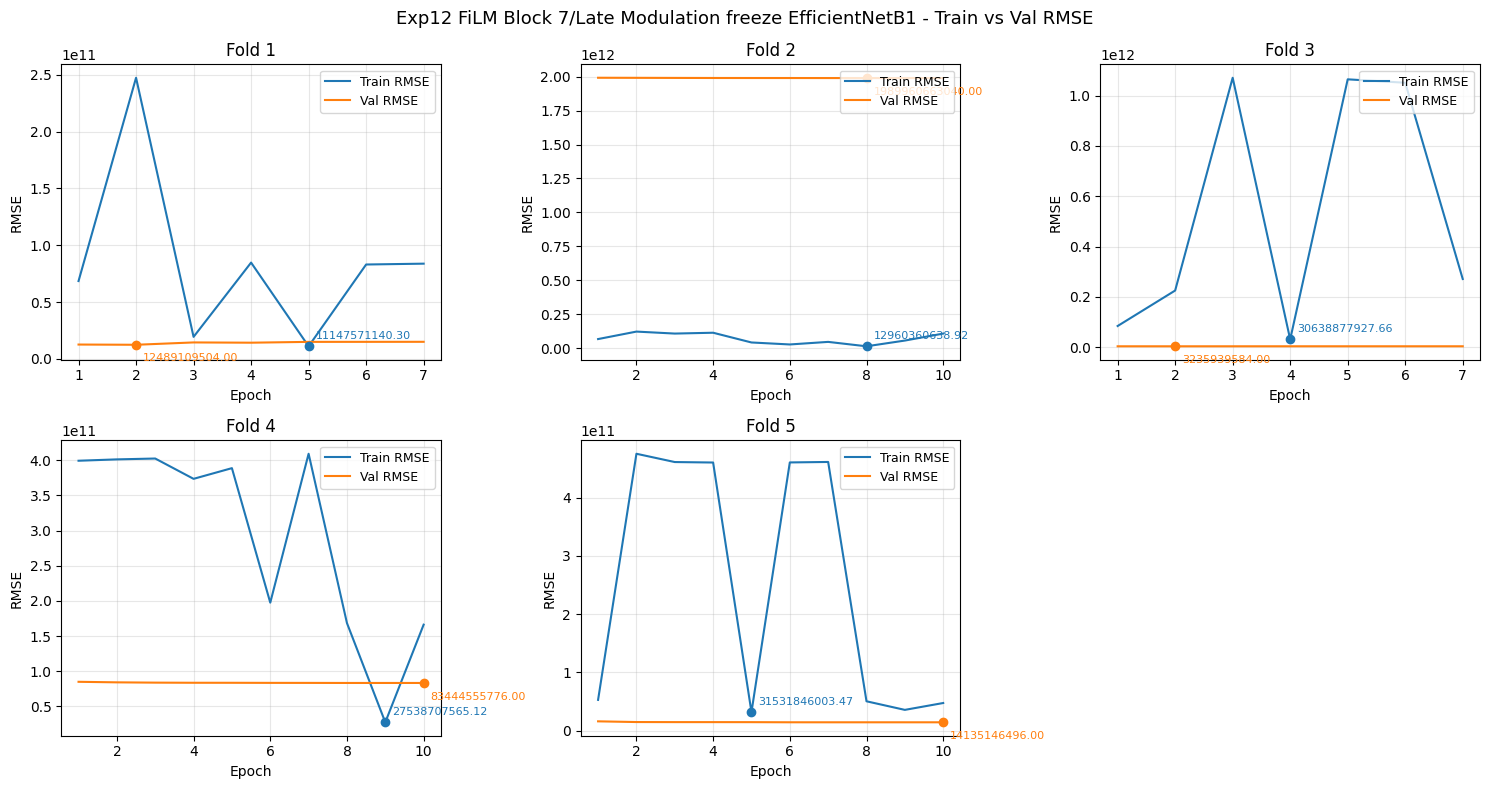

In [7]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM Block 7/Late Modulation freeze EfficientNetB1")